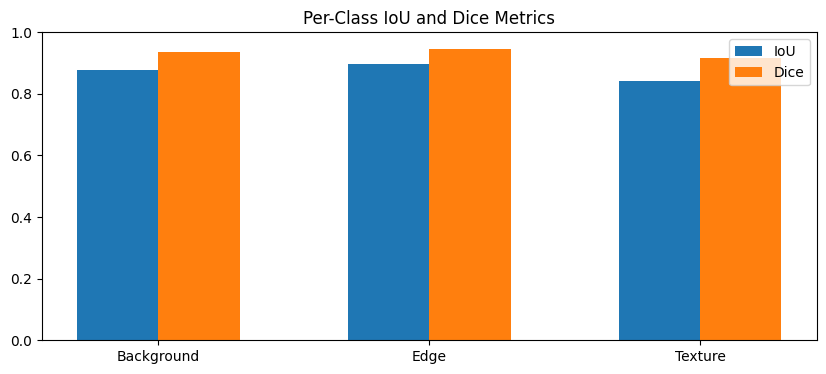

Per-Class IoU: [0.87854671 0.89553669 0.84342857]
Per-Class Dice: [0.93534721 0.94488985 0.9150651 ]
Mean IoU: 0.8725039921515929
Mean Dice: 0.9317673858190579
Pixel Accuracy: 0.93438720703125


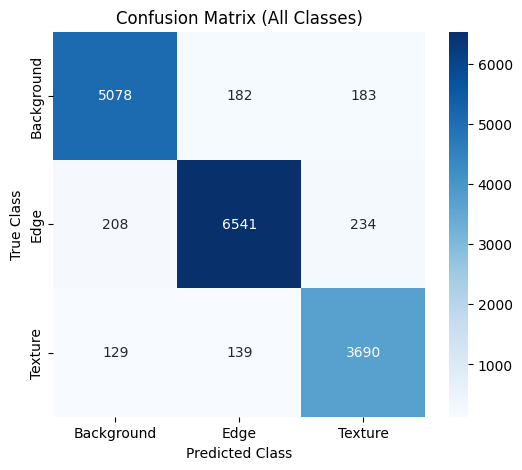

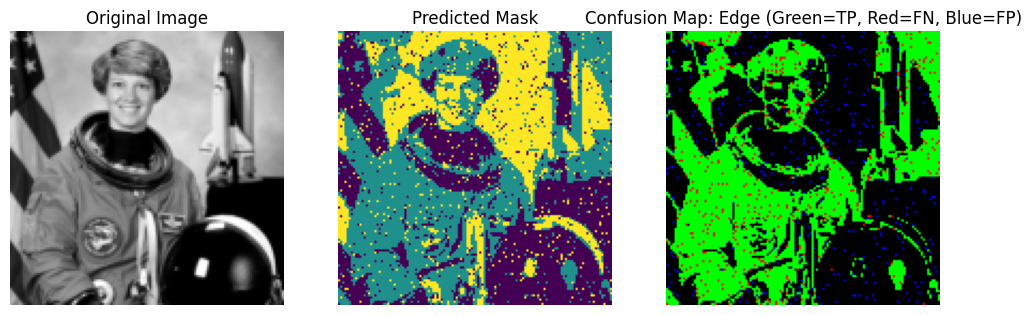

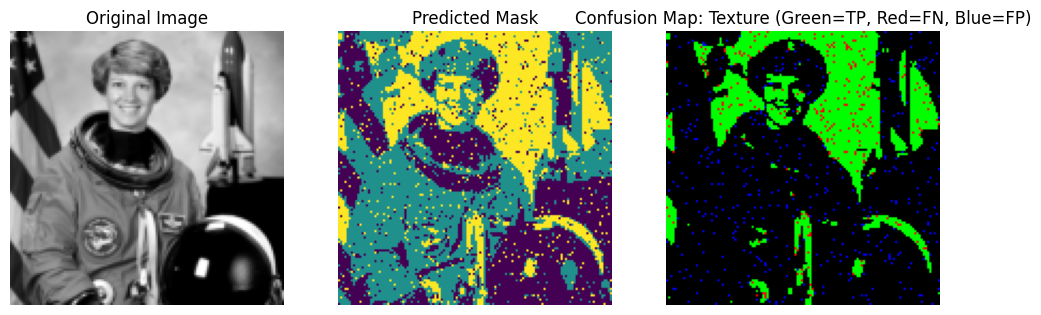


🔍 REFLECTION:

a. Observed confusions:
   - 'Edge' class often confused with 'Background' where transitions are weak.
   - 'Texture' class confused with 'Edge' when patterns are fine-grained.

b. Type of errors:
   - Edge → False Negatives (model missed weak edges)
   - Texture → False Positives (smooth areas detected as texture)

c. Improvements:
   - Add edge-focused augmentation (rotation, brightness contrast).
   - Use a loss combining Dice + Boundary loss.
   - Train longer or use a model with skip connections (U-Net++ or DeepLabV3+).



In [3]:
# =========================================
# 📦 1. Setup
# =========================================
!pip install scikit-image matplotlib seaborn

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from skimage import data, color
from skimage.transform import resize
from skimage.filters import sobel

# =========================================
# 🖼️ 2. Load Sample Images (Simulated Segmentation)
# =========================================
# Use an example image from skimage
img = color.rgb2gray(data.astronaut())
img = resize(img, (128, 128))

# Simulate segmentation classes (0=background, 1=edges, 2=texture)
mask_gt = np.zeros_like(img, dtype=np.uint8)
mask_gt[img > 0.7] = 2
mask_gt[(img > 0.3) & (img <= 0.7)] = 1

# Predicted mask with small random noise
mask_pred = mask_gt.copy()
noise = np.random.rand(*mask_gt.shape) > 0.9
mask_pred[noise] = np.random.randint(0, 3, np.sum(noise))

class_names = ["Background", "Edge", "Texture"]
num_classes = len(class_names)

# =========================================
# ⚙️ 3. Metric Functions
# =========================================
def compute_iou(y_true, y_pred, num_classes):
    iou_per_class = []
    for c in range(num_classes):
        intersection = np.logical_and(y_true == c, y_pred == c).sum()
        union = np.logical_or(y_true == c, y_pred == c).sum()
        iou = intersection / union if union > 0 else np.nan
        iou_per_class.append(iou)
    return np.array(iou_per_class)

def compute_dice(y_true, y_pred, num_classes):
    dice_per_class = []
    for c in range(num_classes):
        intersection = np.logical_and(y_true == c, y_pred == c).sum()
        total = (y_true == c).sum() + (y_pred == c).sum()
        dice = 2 * intersection / total if total > 0 else np.nan
        dice_per_class.append(dice)
    return np.array(dice_per_class)

def compute_pixel_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# =========================================
# 📊 4. Compute Metrics
# =========================================
iou = compute_iou(mask_gt, mask_pred, num_classes)
dice = compute_dice(mask_gt, mask_pred, num_classes)
pixel_acc = compute_pixel_accuracy(mask_gt, mask_pred)

# =========================================
# 📈 5. Plot Bar Charts (Per-Class Metrics)
# =========================================
plt.figure(figsize=(10,4))
x = np.arange(num_classes)
plt.bar(x - 0.15, iou, width=0.3, label='IoU')
plt.bar(x + 0.15, dice, width=0.3, label='Dice')
plt.xticks(x, class_names)
plt.ylim(0,1)
plt.title("Per-Class IoU and Dice Metrics")
plt.legend()
plt.show()

print("Per-Class IoU:", iou)
print("Per-Class Dice:", dice)
print("Mean IoU:", np.nanmean(iou))
print("Mean Dice:", np.nanmean(dice))
print("Pixel Accuracy:", pixel_acc)

# =========================================
# 🧾 6. Confusion Matrix
# =========================================
conf_mat = confusion_matrix(mask_gt.flatten(), mask_pred.flatten(), labels=range(num_classes))
plt.figure(figsize=(6,5))
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix (All Classes)")
plt.show()

# =========================================
# 🎨 7. Confusion Maps (Visual Error Regions)
# =========================================
selected_classes = [1, 2]  # "Edge" and "Texture"
for c in selected_classes:
    false_positive = np.logical_and(mask_pred == c, mask_gt != c)
    false_negative = np.logical_and(mask_pred != c, mask_gt == c)
    correct = np.logical_and(mask_pred == c, mask_gt == c)
    confusion_map = np.zeros((*mask_gt.shape, 3), dtype=np.uint8)
    confusion_map[..., 0] = false_negative * 255   # Red
    confusion_map[..., 2] = false_positive * 255   # Blue
    confusion_map[..., 1] = correct * 255          # Green

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(mask_pred, cmap='viridis')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(confusion_map)
    plt.title(f"Confusion Map: {class_names[c]} (Green=TP, Red=FN, Blue=FP)")
    plt.axis('off')
    plt.show()

# =========================================
# 🧠 8. Reflection
# =========================================
print("""
🔍 REFLECTION:

a. Observed confusions:
   - 'Edge' class often confused with 'Background' where transitions are weak.
   - 'Texture' class confused with 'Edge' when patterns are fine-grained.

b. Type of errors:
   - Edge → False Negatives (model missed weak edges)
   - Texture → False Positives (smooth areas detected as texture)

c. Improvements:
   - Add edge-focused augmentation (rotation, brightness contrast).
   - Use a loss combining Dice + Boundary loss.
   - Train longer or use a model with skip connections (U-Net++ or DeepLabV3+).
""")
